In [3]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [42]:
corpus = [
    "O rei governa o reino com sabedoria.",
    "A rainha governa o reino com justiça.",
    "O rei vive no castelo real.",
    "A rainha mora no castelo com o rei.",
    "O rei é casado com a rainha.",
    "A rainha é casada com o rei.",
    "O rei protege o reino com seu exército.",
    "A rainha cuida do povo com carinho.",
    "O rei e a rainha lideram o povo juntos.",
    "O rei é um homem sábio.",
    "A rainha é uma mulher forte.",
    "O homem trabalha no campo todos os dias.",
    "A mulher trabalha no mercado da cidade.",
    "O homem caça na floresta.",
    "A mulher prepara refeições para a família.",
    "O rei comanda as tropas.",
    "A rainha lidera os conselheiros.",
    "O rei e a rainha tomam decisões importantes.",
    "O homem respeita a rainha.",
    "A mulher respeita o rei.",
    "O castelo é o lar do rei e da rainha.",
    "A mulher visita o castelo para falar com a rainha.",
    "O homem visita o castelo para falar com o rei.",
    "O rei cavalga pelas terras do reino.",
    "A rainha caminha pelos jardins do castelo.",
    "O homem constrói casas no vilarejo.",
    "A mulher ensina as crianças da aldeia.",
    "O rei dá ordens aos guardas.",
    "A rainha recebe os embaixadores no salão real.",
    "O homem planta trigo na lavoura.",
    "A mulher colhe frutas no pomar.",
    "O rei consulta os sábios do reino.",
    "A rainha organiza festas para o povo.",
    "O rei e o homem discutem sobre as leis do reino.",
    "A rainha e a mulher conversam sobre os deveres do lar.",
    "O rei e a rainha são os líderes do reino.",
    "O homem é leal ao rei.",
    "A mulher é fiel à rainha.",
    "O rei delega tarefas aos conselheiros.",
    "A rainha instrui as jovens da corte.",
]
# Tokenização
sentences = [frase.lower().split() for frase in corpus]


In [43]:
model = Word2Vec(
    sentences,            # corpus tokenizado
    vector_size=100,      # dimensão do vetor (ex: 100, 300)
    window=5,             # janela de contexto
    min_count=1,          # ignora palavras com frequência < 1
    workers=4,            # número de threads
    sg=1                  # skip-gram (1) ou CBOW (0)
)

In [44]:
palavras = ['rei', 'rainha', 'homem', 'mulher', 'reino']
vetores = [model.wv[p] for p in palavras]

In [45]:
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

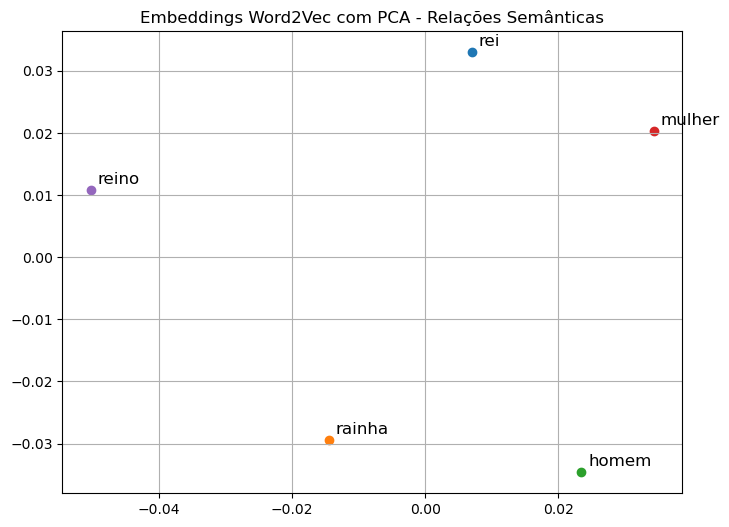

In [46]:
# Plotar
plt.figure(figsize=(8, 6))
for i, palavra in enumerate(palavras):
    x, y = vetores_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.001, y + 0.001, palavra, fontsize=12)

plt.title("Embeddings Word2Vec com PCA - Relações Semânticas")
plt.grid(True)
plt.show()

In [47]:
resultado = model.wv.most_similar(positive=["rei", "mulher"], negative=["homem"])

In [48]:
resultado

[('lavoura.', 0.3274398744106293),
 ('cuida', 0.21710726618766785),
 ('vive', 0.20513573288917542),
 ('castelo', 0.20299620926380157),
 ('as', 0.19648584723472595),
 ('cavalga', 0.1892470270395279),
 ('tomam', 0.18169517815113068),
 ('casada', 0.15348459780216217),
 ('sobre', 0.14667318761348724),
 ('na', 0.1418662667274475)]